# 02 - Profiling and validation

First I profile the raw files as they are, then narrow down to trips that start at JFK and end in Manhattan.
The point is to find the problems that would actually change the KPI, and turn each one into a rule with a
business reason. The pipeline keeps every candidate trip in `trips_validated` with one true/false column per
rule, so any exclusion can be looked up later.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # so we can import the pipeline package

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from pipeline import config, validate

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
con = duckdb.connect()
con.execute("SET memory_limit = '3GB'")
q = lambda sql: con.sql(sql).df()

In [2]:
glob = str(config.RAW_DIR / "trips" / "yellow_tripdata_*.parquet")
_ = con.execute(f'''CREATE VIEW trips AS
    SELECT *, substr(filename, -15, 7) AS file_month
    FROM read_parquet('{glob}', filename=true, union_by_name=true)''')
_ = con.execute(f"CREATE TABLE zones AS SELECT * FROM read_csv('{config.RAW_DIR / 'taxi_zone_lookup.csv'}')")

## Whole-file profile (all trips, all three months)


In [3]:
q('''SELECT file_month, count(*) AS trips,
       round(avg(CASE WHEN passenger_count IS NULL THEN 1 ELSE 0 END), 4) AS null_passenger_share,
       round(avg(CASE WHEN RatecodeID IS NULL THEN 1 ELSE 0 END), 4) AS null_ratecode_share,
       count(*) FILTER (WHERE tpep_dropoff_datetime <= tpep_pickup_datetime) AS dropoff_not_after_pickup,
       count(*) FILTER (WHERE trip_distance = 0) AS zero_distance,
       count(*) FILTER (WHERE fare_amount < 0) AS negative_fare,
       count(*) FILTER (WHERE PULocationID IN (264, 265) OR DOLocationID IN (264, 265)) AS unknown_zone
     FROM trips GROUP BY 1 ORDER BY 1''')

,file_month,trips,null_passenger_share,null_ratecode_share,dropoff_not_after_pickup,zero_distance,negative_fare,unknown_zone
0,2026-04,3831240,0.2088,0.2088,49511,93515,14328,23623
1,2026-05,4090836,0.2335,0.2335,52063,113031,14231,25260
2,2026-06,3837248,0.2641,0.2641,49807,128106,13648,26966


In [4]:
q('''SELECT RatecodeID IS NULL AS ratecode_null, payment_type, count(*) AS trips
     FROM trips GROUP BY ALL ORDER BY trips DESC''')

,ratecode_null,payment_type,trips
0,False,1,7796205
1,True,0,2768657
2,False,2,1091708
3,False,4,67771
4,False,3,34981
5,False,5,2


A fifth or more of every file has no RatecodeID and no passenger_count, and every one of those rows has
payment_type 0, which the data dictionary calls "Flex Fare trip". Flex Fare is upfront app pricing, and those
trips just don't fill these two fields. For this project it means a null rate code can't be read as
"probably flat fare".

## Where do JFK pickups go?


In [5]:
q('''SELECT z.Borough AS dropoff_borough, count(*) AS trips,
       count(*) FILTER (WHERE RatecodeID = 2) AS ratecode_2
     FROM trips t LEFT JOIN zones z ON t.DOLocationID = z.LocationID
     WHERE t.PULocationID = 132 GROUP BY 1 ORDER BY 2 DESC''')

,dropoff_borough,trips,ratecode_2
0,Manhattan,212688,202510
1,Queens,126852,2953
2,Brooklyn,76893,418
3,N/A,20272,58
4,Bronx,7890,70
5,Staten Island,800,0
6,EWR,417,0
7,Unknown,356,182


Manhattan is the biggest destination from the JFK rank. Queens trips are mostly short local runs.
"N/A" is zone 265 (Outside of NYC) and "Unknown" is zone 264. I can't tell whether the 264 trips went to
Manhattan, so they stay out of the run definition and are counted in check S08.

## How should a "JFK -> Manhattan run" be defined?

Two options: by the zone pair (pickup zone 132, dropoff in a Manhattan zone) or by RatecodeID = 2 (the JFK flat fare).


In [6]:
q('''SELECT coalesce(CAST(RatecodeID AS VARCHAR), 'null') AS ratecode, count(*) AS trips,
       median(fare_amount) AS median_fare,
       round(median(date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) / 60.0), 1) AS median_min
     FROM trips t JOIN zones z ON t.DOLocationID = z.LocationID
     WHERE t.PULocationID = 132 AND z.Borough = 'Manhattan'
     GROUP BY 1 ORDER BY 2 DESC''')

,ratecode,trips,median_fare,median_min
0,2,202510,70.0,52.5
1,1,5496,80.0,56.4
2,5,3172,85.0,49.6
3,3,880,98.6,59.3
4,null,598,70.0,50.4
5,4,28,140.2,59.6
6,99,4,52.5,38.0


In [7]:
q('''WITH m AS (SELECT LocationID FROM zones WHERE Borough = 'Manhattan')
     SELECT CASE WHEN PULocationID = 132 AND DOLocationID IN (SELECT * FROM m) THEN 'JFK -> Manhattan'
                 WHEN DOLocationID = 132 AND PULocationID IN (SELECT * FROM m) THEN 'Manhattan -> JFK'
                 WHEN PULocationID = 132 OR DOLocationID = 132 THEN 'JFK <-> somewhere else'
                 ELSE 'does not touch JFK' END AS trip_type,
            count(*) AS ratecode_2_trips
     FROM trips WHERE RatecodeID = 2 GROUP BY 1 ORDER BY 2 DESC''')

,trip_type,ratecode_2_trips
0,JFK -> Manhattan,202510
1,Manhattan -> JFK,53024
2,does not touch JFK,18520
3,JFK <-> somewhere else,4669


This is the judgement call I spent the most time on. RatecodeID is typed in by the driver. Only about 73% of
RatecodeID 2 trips are the run the fleet manager is asking about. The rest are mostly the opposite direction
(Manhattan -> JFK, a different traffic pattern and not a queue decision), plus trips that don't touch JFK at
all, which shouldn't have the JFK rate. Going the other way, about 95% of JFK -> Manhattan zone-pair trips carry
rate code 2. The rest are metered (code 1), negotiated (5), flex fare (null) or clearly wrong (3 = Newark).

So I define the run by the zone pair, because that's the actual workflow (pickup at the JFK rank, drop in
Manhattan). Then I use the rate code as a scope filter: the KPI is about flat-fare economics, so non-flat-fare
trips inside the zone pair are excluded as "out of scope" (rule V06) and counted, not treated as bad data.
Notebook 03 shows how much the hourly advice would change with the rate-code-only definition.

## Trip duration inside the zone pair


In [8]:
_ = con.execute('''CREATE TABLE cand AS
    SELECT t.*, date_diff('second', tpep_pickup_datetime, tpep_dropoff_datetime) / 60.0 AS duration_min
    FROM trips t JOIN zones z ON t.DOLocationID = z.LocationID
    WHERE t.PULocationID = 132 AND z.Borough = 'Manhattan' ''')
q('''SELECT count(*) AS trips,
       count(*) FILTER (WHERE duration_min <= 0) AS "<= 0 min",
       count(*) FILTER (WHERE duration_min > 0 AND duration_min < 10) AS "0-10 min",
       count(*) FILTER (WHERE duration_min > 180) AS "> 180 min",
       count(*) FILTER (WHERE duration_min > 600) AS "> 10 hours",
       round(max(duration_min) / 60, 1) AS max_hours
     FROM cand''')

,trips,<= 0 min,0-10 min,> 180 min,> 10 hours,max_hours
0,212688,2148,36,123,55,41.4


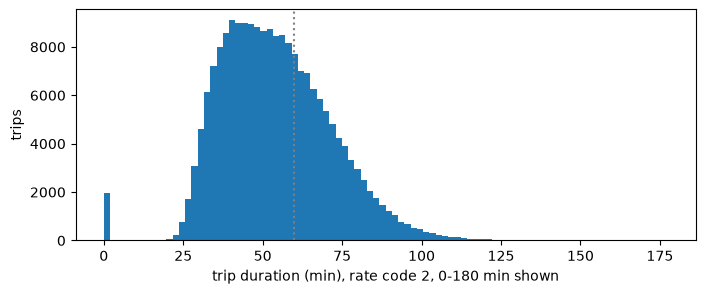

In [9]:
d = q("SELECT duration_min FROM cand WHERE RatecodeID = 2 AND duration_min BETWEEN 0 AND 180")
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(d.duration_min, bins=90)
ax.axvline(60, color="gray", linestyle=":")
ax.set_xlabel("trip duration (min), rate code 2, 0-180 min shown")
ax.set_ylabel("trips")
plt.show()

There's a spike at exactly 0 minutes. Looking at who sends those rows:


In [10]:
q('''SELECT VendorID, count(*) AS trips,
       count(*) FILTER (WHERE tpep_dropoff_datetime <= tpep_pickup_datetime) AS dropoff_not_after_pickup,
       round(avg(CASE WHEN tpep_dropoff_datetime <= tpep_pickup_datetime THEN 1 ELSE 0 END), 4) AS share
     FROM trips GROUP BY 1 ORDER BY 1''')

,VendorID,trips,dropoff_not_after_pickup,share
0,1,2179914,751,0.0003
1,2,9402691,91,0.0000
2,6,26181,1,0.0000
3,7,150538,150538,1.0000


In [11]:
q('''SELECT VendorID, count(*) AS trips, count(*) FILTER (WHERE duration_min <= 0) AS zero_or_negative,
       median(fare_amount) AS median_fare, median(trip_distance) AS median_miles
     FROM cand GROUP BY 1 ORDER BY 1''')

,VendorID,trips,zero_or_negative,median_fare,median_miles
0,1,26614,0,70.0,17.80
1,2,183925,0,70.0,17.92
2,6,1,0,0.0,15.91
3,7,2148,2148,70.0,17.66


Every single trip from VendorID 7 (Helix) has dropoff time equal to pickup time, in all three months, in the
whole file. Their fares and distances look normal, so the trips are real, but the dropoff timestamp is not being
filled. It's 100% of this vendor's trips and almost never happens for the other vendors (843 of about 11.6
million trips), so I think it's in how Helix sends its records to TLC. I don't try to impute a duration for these trips (that would be making up the
number the KPI depends on). Rule V02 excludes them, check S05 warns about the vendor on
every run, and it's the first thing I would raise with the client / TLC. It's about 1% of JFK -> Manhattan trips,
so it doesn't move the KPI much, but it would bias it if Helix cabs work at different hours than the others.

## Fares


In [12]:
q('''SELECT fare_amount, count(*) AS trips FROM cand WHERE RatecodeID = 2
     GROUP BY 1 ORDER BY 2 DESC LIMIT 6''')

,fare_amount,trips
0,70.00,201202
1,-70.00,1233
2,0.00,33
3,84.21,14
4,73.50,9
5,78.50,7


In [13]:
q('''SELECT payment_type, count(*) AS trips FROM cand WHERE RatecodeID = 2 AND fare_amount <= 0
     GROUP BY 1 ORDER BY 2 DESC''')

,payment_type,trips
0,4,768
1,2,376
2,3,115
3,1,7


Almost every flat-fare trip is exactly $70, which matches the JFK flat fare. The -$70 rows are mostly
payment_type 4 (dispute) and 2 (cash), which look like reversals or voids, not a completed paid run.
They're excluded by V05. The few odd positive fares ($73.50, $84.21...) are kept but flagged (F02),
and the actual fare is what goes into $/trip-hour.

## Mean vs median

The metrics use median and P90, not the mean. Here is why:


In [14]:
q('''SELECT 'all zone-pair trips, no rules' AS population, count(*) AS trips,
       round(avg(duration_min), 1) AS mean_min, round(median(duration_min), 1) AS median_min
     FROM cand
     UNION ALL
     SELECT 'only the <= 0 min trips', count(*), round(avg(duration_min), 1), round(median(duration_min), 1)
     FROM cand WHERE duration_min <= 0
     UNION ALL
     SELECT 'only the > 180 min trips', count(*), round(avg(duration_min), 1), round(median(duration_min), 1)
     FROM cand WHERE duration_min > 180
     UNION ALL
     SELECT 'after exclude rules (V01-V06)', count(*), round(avg(duration_min), 1), round(median(duration_min), 1)
     FROM cand WHERE RatecodeID = 2 AND duration_min BETWEEN 10 AND 180 AND fare_amount > 0
                 AND strftime(tpep_pickup_datetime, '%Y-%m') = file_month''')

,population,trips,mean_min,median_min
0,"all zone-pair trips, no rules",212688,54.5,52.5
1,only the <= 0 min trips,2148,0.0,0.0
2,only the > 180 min trips,123,712.0,525.3
3,after exclude rules (V01-V06),199156,54.6,52.7


The mean hardly moves between raw and cleaned data. That's because the zero-minute Helix trips pull it
down and the meters left running for hours pull it up, and in these months they roughly cancel out. Next month
they might not.
The median is much less sensitive to this kind of junk, and P90 describes the slow tail, which is what a driver
actually worries about when deciding to sit in the queue.

## The rules the pipeline applies

Each rule is SQL in `pipeline/validate.py`. The thresholds live in `pipeline/config.py`.


In [15]:
pd.DataFrame(validate.TRIP_RULES, columns=["rule_id", "rule", "sql", "severity", "action", "business_reason"])[
    ["rule_id", "rule", "severity", "action", "business_reason"]]

,rule_id,rule,severity,action,business_reason
0,V01,pickup outside the file's month,high,exclude,clock error or late record; it would leak into the wrong month's KPI
1,V02,dropoff at or before pickup,high,exclude,"trip time can't be measured, and trip time is the whole question"
2,V03,duration under 10 min,high,exclude,"JFK to Manhattan is 13+ miles, under 10 min is not a real run"
3,V04,duration over 180 min,medium,exclude,meter most likely left running; would inflate P90 and long-trip rate
4,V05,fare zero or negative,medium,exclude,"refund, void or dispute reversal, not a completed paid run"
5,V06,rate code is not the JFK flat fare (2),scope,exclude (out of scope),"metered, negotiated, flex-fare or missing code; flat-fare economics don't apply"
6,F01,distance under 5 miles,low,"flag, keep",distance meter can fail on a real trip; duration and fare still look normal
7,F02,flat-fare trip with fare other than $70,low,"flag, keep","flat fare should be exactly $70; kept, and the actual fare is used in $/hour"
8,F03,passenger_count is 0,low,"flag, keep","driver-entered field, not used by any metric"


## Rule counts from the last pipeline run

This is `outputs/validation_report.csv`. `share` is out of all JFK -> Manhattan zone-pair trips that month.


In [16]:
report = pd.read_csv(config.OUTPUT_DIR / "validation_report.csv")
report.pivot_table(index=["rule_id", "rule", "action"], columns="month", values="rows_hit").astype(int)

,,month,2026-04,2026-05,2026-06
rule_id,rule,action,,,
F01,distance under 5 miles,"flag, keep",85,118,109
F02,flat-fare trip with fare other than $70,"flag, keep",11,12,19
F03,passenger_count is 0,"flag, keep",103,123,85
V01,pickup outside the file's month,exclude,0,0,1
V02,dropoff at or before pickup,exclude,594,773,781
V03,duration under 10 min,exclude,13,9,14
V04,duration over 180 min,exclude,50,38,35
V05,fare zero or negative,exclude,492,494,449
V06,rate code is not the JFK flat fare (2),exclude (out of scope),3311,3621,3246


Can one trip break more than one rule? I count it from the audit table the pipeline saved:


In [17]:
db = duckdb.connect(str(config.DB_PATH), read_only=True)
db.sql('''SELECT v01::INT + v02::INT + v03::INT + v04::INT + v05::INT AS quality_rules_broken,
                v06 AS out_of_scope, count(*) AS trips
         FROM trips_validated GROUP BY ALL ORDER BY 1, 2''').df()

,quality_rules_broken,out_of_scope,trips
0,0,False,199156
1,0,True,9789
2,1,False,3354
3,1,True,389


No trip breaks two of the quality rules V01-V05 at once (for example none of the Helix trips has a zero or
negative fare). The only overlap is between a quality rule and V06: 389 trips are both off the flat fare and
broken in some other way. That's why the per-rule counts add up to more than the unique exclusions
(3,743 quality + 9,789 out of scope only).

The file-level checks for one month (`outputs/pipeline_checks.csv`):


In [18]:
checks = pd.read_csv(config.OUTPUT_DIR / "pipeline_checks.csv", dtype={"value": str})
checks[checks.month == "2026-06"][["check_id", "check", "severity", "status", "value", "detail"]]

,check_id,check,severity,status,value,detail
28,S01,required columns present,FAIL-level,PASS,0,columns not in the data dictionary (ignored): request_source
29,S02,rows loaded = rows in parquet footer,FAIL-level,PASS,3837248,parquet metadata says 3837248
30,S03,share of pickups inside the file's month,FAIL-level,PASS,0.999996,threshold 0.999
31,S04,every day of the month has trips,FAIL-level,PASS,30,30 days expected
32,S05,vendors with unusable dropoff timestamps,WARN-level,WARN,1,VendorID 7: 100.0% of 49524 trips have dropoff <= pickup
33,S06,share of rows with null RatecodeID,INFO,INFO,0.2641,26.41% of all rows are null RatecodeID with payment_type 0 (Flex Fare)
34,S07,RatecodeID 2 trips that are not JFK -> Manhattan,INFO,INFO,25176,"of 92624 RatecodeID 2 trips: 67448 JFK->Manhattan, 17625 Manhattan->JFK, 5930 touch neither end at JFK"
35,S08,JFK pickups with unknown / outside-NYC dropoff zone,INFO,INFO,6843,"137 to zone 264 (Unknown), 6706 to zone 265 (Outside of NYC); not counted as Manhattan runs"
36,S09,weather hours complete,WARN-level,PASS,1,720 hours expected
37,S10,row count within 15% of previous month,WARN-level,PASS,-0.062,3837248 rows vs 4090836 in 2026-05


## Assumptions and things I chose not to fix

- The 60-minute threshold is my choice, not a TLC rule. At $70, a 60-minute trip is $70 per hour on the meter.
  The median trip in the whole data is around 53 minutes, so "over an hour" means a clearly worse than
  typical trip.
- 10 and 180 minutes as plausible bounds are judgement. Changing them moves very few trips (see V03/V04 counts).
- Trips under 5 miles are kept. Their times and fares look like normal runs, so I think the distance meter failed,
  not the trip.
- Holidays (Memorial Day, Juneteenth) are counted as weekdays.
- Zone 264 "Unknown" dropoffs from JFK are left out of the run even though some of them are probably Manhattan.
